In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, run_xso_stabilityscan, avg_tail

import cariaco_obs as co
import cariaco_baseline_setups as cbs
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cbs, pu, pp):            # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')

grid: 40 phyto (0.2–200 µm), 40 zoo (2–2000 µm)


upwelling  T=23.0°C  CV(ΣP)=0.008   model mcs=7.13 µm   obs mcs=4.84 µm
relaxed    T=25.4°C  CV(ΣP)=0.002   model mcs=2.50 µm   obs mcs=2.01 µm


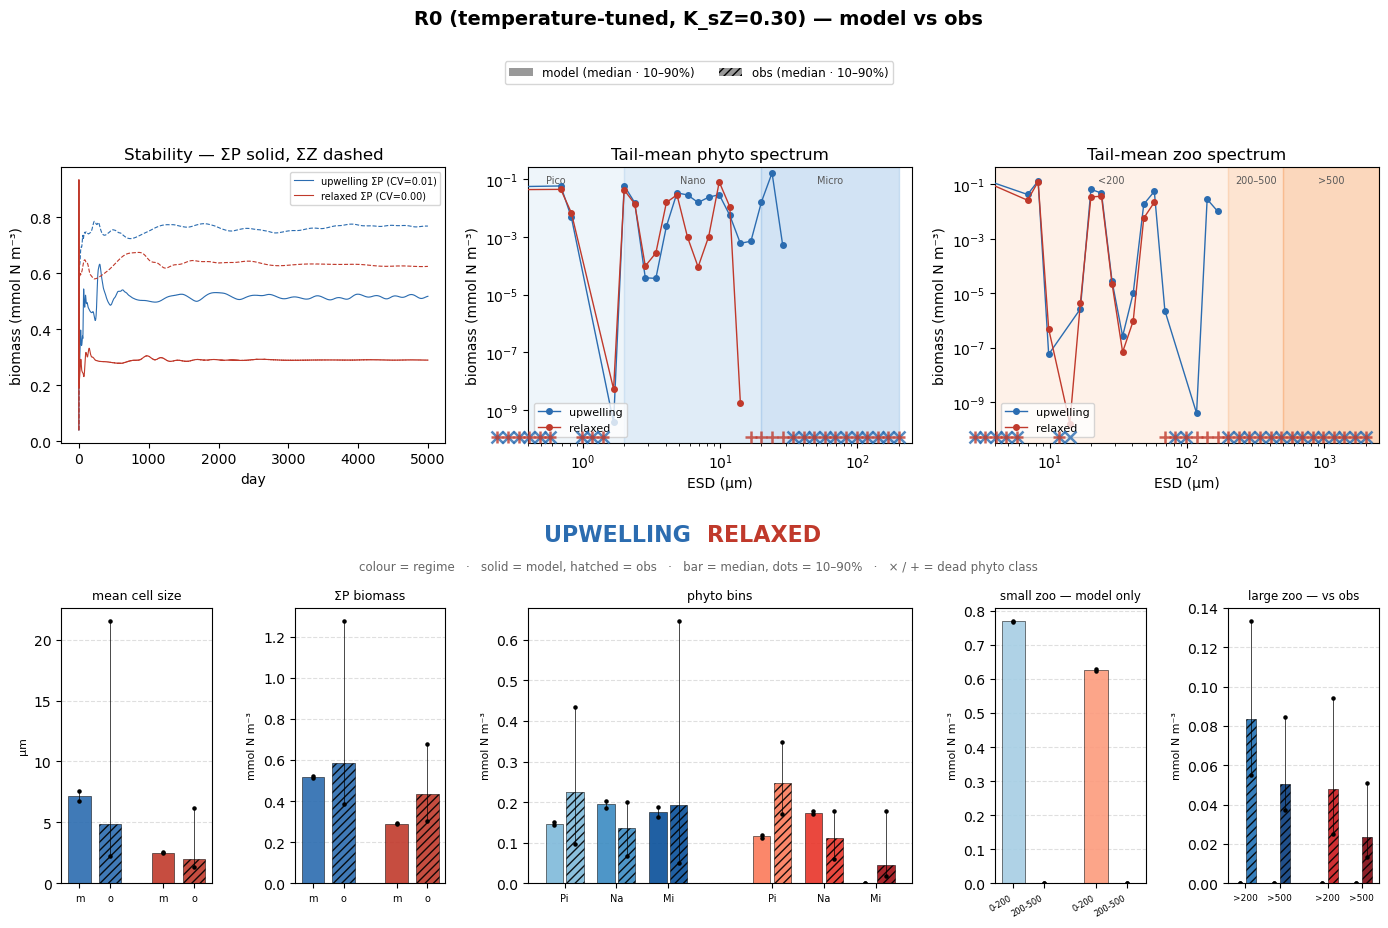

In [2]:
# ── Cell 5 (temp-tuned R0) — IVP per regime → tail-mean vs obs, Fig 4 ────────
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_baseline_setups as cbs, cariaco_obs as co
import parscan_utils as pu, parscan_plots as pp
for m in (cbs, co, pu, pp):
    importlib.reload(m)

regimes  = ('upwelling', 'relaxed')
bin_defs = co.TARGET_BIN_DEFINITIONS
phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
TAIL = 1000

# tuned R0: temperature ON, obs-fit K_sZ = 0.30, m_Z = 0.3
ksz_arr  = np.full(len(zoo_esd), 0.30)
tuned_ov = {'Grazing__KsZ': ksz_arr, 'ZooLoss__rate': 0.3}

# regime forcings WITH temperature (Temperature__value added by include_temperature)
targets = {}
for r in regimes:
    *_, mdf, forc = co.load_cariaco_targets(regime=r, months='hplc',
                                            agg='median', include_temperature=True)
    targets[r] = {'forcing': forc, 'monthly_df': mdf}

model_by_regime, obs_by_regime = {}, {}
for r in regimes:
    out = pu.run_single_point(cbs.model_dist_t3_T, cbs.model_setup_dist_herb_t3_T_slim,
                              scan_params={},
                              fixed_overrides={**targets[r]['forcing'], **tuned_ov})
    model_by_regime[r] = pu.process_regime_run(out, phyto_esd, zoo_esd, bin_defs, tail_len=TAIL)
    obs_by_regime[r]   = pu.process_regime_obs(targets[r]['monthly_df'], bin_defs)
    print(f"{r:10s} T={targets[r]['forcing']['Temperature__value']:.1f}°C  "
          f"CV(ΣP)={model_by_regime[r]['cv']:.3f}   "
          f"model mcs={np.nanmedian(model_by_regime[r]['mcs_tail']):.2f} µm   "
          f"obs mcs={np.nanmedian(obs_by_regime[r]['mcs']):.2f} µm")

fig = pp.plot_regime_diagnostic(model_by_regime, obs_by_regime, phyto_esd, zoo_esd,
                                regimes=regimes,
                                title='R0 (temperature-tuned, K_sZ=0.30) — model vs obs')
#fig.savefig('fig4_regime_diagnostic.png', dpi=150, bbox_inches='tight')  # drops into the deck slide
plt.show()

In [2]:
# ── Fish test: R0 vs R0+fish (Rykaczewski) at regime forcings (K_sZ=0.3) ──────
import importlib, numpy as np
import cariaco_baseline_setups as cbs, cariaco_obs as co, run_baseline_diagnostic as rbd
from parscan_utils import aggregate_model_to_targets, compute_phyto_spectrum_metrics
from cariaco_obs import TARGET_BIN_DEFINITIONS
for m in (cbs, co, rbd):
    importlib.reload(m)

pe, ze = cbs.phyto_esd, cbs.zoo_esd; logpe = np.log10(pe)
pbd = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']
ksz_arr = np.full(len(ze), 0.3); MZ = 0.3
def mcs(P): a = P > 1e-6; t = P[a].sum(); return 10**np.sum((P[a]/t)*logpe[a]) if t > 0 else np.nan
def summ(model, setup, ov):
    st = rbd.extract_state(rbd.run_setup(model, setup, input_vars_override=ov))
    Pt = np.clip(st['P'][:, -1000:].mean(1), 0, None); Zt = st['Z'][:, -1000:].mean(1)
    sP = st['P'].sum(0)[-1000:]
    fr = (lambda v: np.array(v)/np.sum(v))(aggregate_model_to_targets({'phyto': Pt}, pe, ze, pbd))
    return mcs(Pt), sP.std()/abs(sP.mean()), fr, Pt.sum(), Zt.sum()

for r in ('upwelling', 'relaxed'):
    obs_vec, _, _, mdf, forc = co.load_cariaco_targets(regime=r, months='hplc', agg='median', include_temperature=True)
    pv = np.array(obs_vec[:len(pbd)]); obs_fr = pv/pv.sum()
    obs_m = 10**compute_phyto_spectrum_metrics(pv, pbd)['centroid']
    base = {'Inflow': {'FN': forc['Inflow__FN'], 'de': forc['Inflow__de']},
            'Temperature': {'value': forc['Temperature__value']},
            'Grazing': {'KsZ': ksz_arr}, 'ZooLoss': {'rate': MZ}}
    print(f"\n{r}  T={forc['Temperature__value']:.1f}°C  "
          f"obs mcs={obs_m:.2f}µm  P/N/M={obs_fr[0]:.2f}/{obs_fr[1]:.2f}/{obs_fr[2]:.2f}")
    for tag, model, setup in [('R0 (no fish)', cbs.model_dist_t3_T, cbs.model_setup_dist_herb_t3_T_slim),
                              ('R0 + fish   ', cbs.model_dist_t3_T_fish, cbs.model_setup_dist_herb_t3_T_fish_slim)]:
        m, cv, fr, sp, sz = summ(model, setup, base)
        print(f"  {tag}: mcs={m:.2f}µm  CV={cv:.3f}  P/N/M={fr[0]:.2f}/{fr[1]:.2f}/{fr[2]:.2f}  ΣP={sp:.2f}  ΣZ={sz:.2f}")


upwelling  T=23.0°C  obs mcs=5.50µm  P/N/M=0.41/0.25/0.35
  R0 (no fish): mcs=4.68µm  CV=0.008  P/N/M=0.28/0.38/0.34  ΣP=0.52  ΣZ=0.77
  R0 + fish   : mcs=4.68µm  CV=0.007  P/N/M=0.28/0.39/0.34  ΣP=0.52  ΣZ=0.77

relaxed  T=25.4°C  obs mcs=2.00µm  P/N/M=0.61/0.28/0.11
  R0 (no fish): mcs=2.28µm  CV=0.002  P/N/M=0.40/0.60/0.00  ΣP=0.29  ΣZ=0.63
  R0 + fish   : mcs=2.27µm  CV=0.002  P/N/M=0.40/0.60/0.00  ΣP=0.29  ΣZ=0.62


In [3]:
# ── Fish-rate 1D parscan (parallel), per regime ──────────────────────────────
import importlib, numpy as np
import cariaco_baseline_setups as cbs, cariaco_obs as co, parscan_utils as pu
for m in (cbs, co, pu):
    importlib.reload(m)
from xso.parscans import run_xso_parscan
from parscan_utils import aggregate_model_to_targets
from cariaco_obs import TARGET_BIN_DEFINITIONS

pe, ze = cbs.phyto_esd, cbs.zoo_esd; logpe = np.log10(pe)
pbd = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']
ksz_arr = np.full(len(ze), 0.3)
fish_zone = cbs.kernel_Z_fish > 0.5          # zoo classes fish actually grazes
fish_rates = np.linspace(0.0, 0.5, 11)       # 0 = no fish ... 100× the default
TAIL = 1000
def mcs(P): a = P > 1e-6; t = P[a].sum(); return 10**np.sum((P[a]/t)*logpe[a]) if t > 0 else np.nan

for r in ('upwelling', 'relaxed'):
    *_, forc = co.load_cariaco_targets(regime=r, months='hplc', agg='median', include_temperature=True)
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups', model_name='model_dist_t3_T_fish',
        model_setup_name='model_setup_dist_herb_t3_T_fish_slim',
        param_name='FishGrazing__rate', param_values=fish_rates, processes=8,
        fixed_overrides={**forc, 'Grazing__KsZ': ksz_arr, 'ZooLoss__rate': 0.3})
    print(f"\n{r}  (T={forc['Temperature__value']:.1f}, F_N={forc['Inflow__FN']:.2f}):")
    for k in range(len(fish_rates)):
        Pt = np.clip(res.Phytoplankton__biomass.isel({'FishGrazing__rate': k}).isel(time=slice(-TAIL, None)).mean('time').values, 0, None)
        Zt = np.clip(res.Zooplankton__biomass.isel({'FishGrazing__rate': k}).isel(time=slice(-TAIL, None)).mean('time').values, 0, None)
        fr = (lambda v: np.array(v)/np.sum(v))(aggregate_model_to_targets({'phyto': Pt}, pe, ze, pbd))
        lz = Zt[fish_zone].sum()/Zt.sum() if Zt.sum() > 0 else 0.0
        print(f"  rate={fish_rates[k]:.3f}: mcs={mcs(Pt):.2f}µm  Micro={fr[2]:.2f}  "
              f"ΣZ={Zt.sum():.3f}  frac-Z-in-fish-zone={lz:.4f}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_fish' and setup 'model_setup_dist_herb_t3_T_fish_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 11 points using 8 workers...
1D Scan complete. Time taken: 33.72781 seconds.

upwelling  (T=23.0, F_N=2.58):
  rate=0.000: mcs=4.68µm  Micro=0.34  ΣZ=0.769  frac-Z-in-fish-zone=0.0000
  rate=0.050: mcs=4.50µm  Micro=0.27  ΣZ=0.759  frac-Z-in-fish-zone=0.0000
  rate=0.100: mcs=4.42µm  Micro=0.23  ΣZ=0.738  frac-Z-in-fish-zone=0.0000
  rate=0.150: mcs=4.26µm  Micro=0.20  ΣZ=0.739  frac-Z-in-fish-zone=0.0000
  rate=0.200: mcs=4.15µm  Micro=0.16  ΣZ=0.731  frac-Z-in-fish-zone=0.0000
  rate=0.250: mcs=4.05µm  Micro=0.09  ΣZ=0.719  frac-Z-in-fish-zone=0.0000
  rate=0.300: mcs=3.89µm  Micro=0.05  ΣZ=0.716  frac-Z-in-fish-zone=0.0000
  rate=0.350: mcs=3.78µm  Micro=0.02  ΣZ=0.710  frac-Z-in-fish

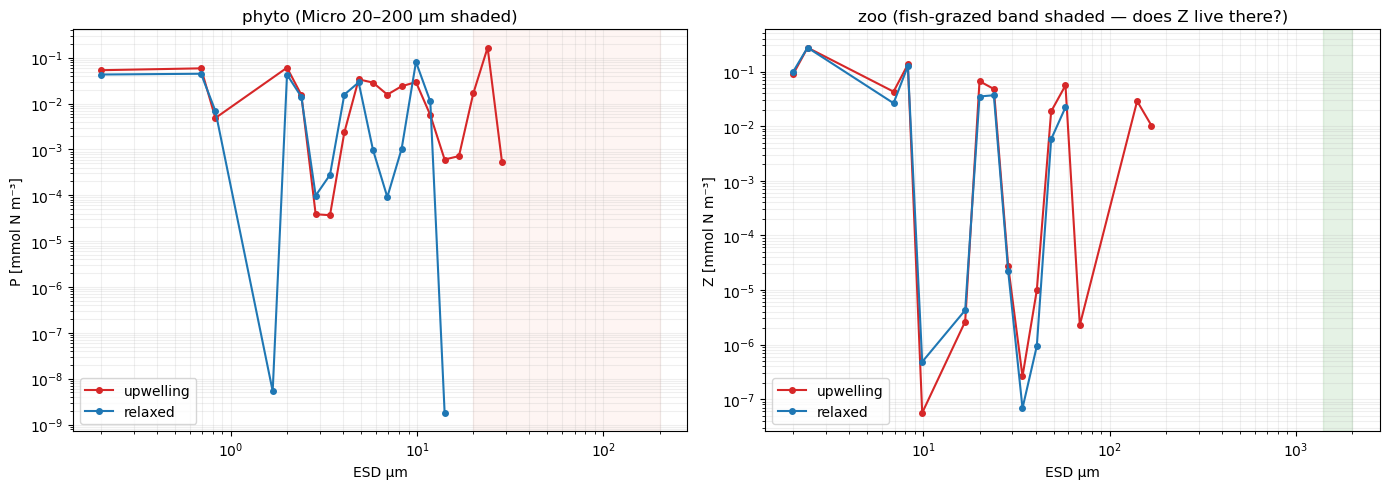

In [4]:
# ── Trophic structure: Z biomass vs where the fish kernel grazes ─────────────
import matplotlib.pyplot as plt, run_baseline_diagnostic as rbd
importlib.reload(rbd)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for r, c in [('upwelling', 'C3'), ('relaxed', 'C0')]:
    *_, forc = co.load_cariaco_targets(regime=r, months='hplc', agg='median', include_temperature=True)
    ov = {'Inflow': {'FN': forc['Inflow__FN'], 'de': forc['Inflow__de']},
          'Temperature': {'value': forc['Temperature__value']},
          'Grazing': {'KsZ': ksz_arr}, 'ZooLoss': {'rate': 0.3}}
    st = rbd.extract_state(rbd.run_setup(cbs.model_dist_t3_T, cbs.model_setup_dist_herb_t3_T_slim, input_vars_override=ov))
    Pt = np.clip(st['P'][:, -1000:].mean(1), 0, None); Zt = np.clip(st['Z'][:, -1000:].mean(1), 0, None)
    ax[0].loglog(pe[Pt > 1e-9], Pt[Pt > 1e-9], 'o-', color=c, ms=4, label=f'{r}')
    ax[1].loglog(ze[Zt > 1e-9], Zt[Zt > 1e-9], 'o-', color=c, ms=4, label=f'{r}')
ax[0].axvspan(20, 200, alpha=.08, color='salmon'); ax[0].set(title='phyto (Micro 20–200 µm shaded)', xlabel='ESD µm', ylabel='P [mmol N m⁻³]')
ax[1].axvspan(ze[fish_zone].min(), 2000, alpha=.10, color='green')
ax[1].set(title='zoo (fish-grazed band shaded — does Z live there?)', xlabel='ESD µm', ylabel='Z [mmol N m⁻³]')
for a in ax:
    a.legend(); a.grid(alpha=.2, which='both')
plt.tight_layout(); plt.show()

In [5]:
# ── Trophic structure across F_N: do large Z form? herbivory vs omnivory ─────
import importlib, numpy as np
import cariaco_baseline_setups as cbs, cariaco_obs as co
for m in (cbs, co):
    importlib.reload(m)
from xso.parscans import run_xso_parscan

ze = cbs.zoo_esd
ksz_arr = np.full(len(ze), 0.3)
fish_zone = cbs.kernel_Z_fish > 0.5                 # the green band (fish-grazed)
*_, forc = co.load_cariaco_targets(regime='upwelling', months='hplc', agg='median', include_temperature=True)
FN_vals = np.linspace(forc['Inflow__FN'], 20.0, 12)  # from the upwelling operating point up to bloom
TAIL = 1000

for tag, setup in [('herbivory', 'model_setup_dist_herb_t3_T_slim'),
                   ('omnivory ', 'model_setup_dist_omni_t3_T_slim')]:
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups', model_name='model_dist_t3_T',
        model_setup_name=setup, param_name='Inflow__FN', param_values=FN_vals, processes=8,
        fixed_overrides={'Inflow__de': forc['Inflow__de'], 'Temperature__value': forc['Temperature__value'],
                         'Grazing__KsZ': ksz_arr, 'ZooLoss__rate': 0.3})
    print(f"\n=== {tag}  (T={forc['Temperature__value']:.1f}, de={forc['Inflow__de']:.0f}) ===")
    for k in range(len(FN_vals)):
        Pt = np.clip(res.Phytoplankton__biomass.isel({'Inflow__FN': k}).isel(time=slice(-TAIL, None)).mean('time').values, 0, None)
        Zt = np.clip(res.Zooplankton__biomass.isel({'Inflow__FN': k}).isel(time=slice(-TAIL, None)).mean('time').values, 0, None)
        lz = Zt[fish_zone].sum()/Zt.sum() if Zt.sum() > 0 else 0.0
        zmax = ze[Zt > 1e-4].max() if (Zt > 1e-4).any() else 0.0
        print(f"  F_N={FN_vals[k]:5.1f}: ΣP={Pt.sum():.2f} ΣZ={Zt.sum():.2f} ΣZ/ΣP={Zt.sum()/max(Pt.sum(),1e-9):.2f} "
              f"frac-fish-zone={lz:.4f} maxZ-ESD={zmax:.0f}µm")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_herb_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3824 on P[13] = -0.00132. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=4756 on P[14] = -0.00124. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


1D Scan complete. Time taken: 30.97804 seconds.

=== herbivory  (T=23.0, de=43) ===
  F_N=  2.6: ΣP=0.52 ΣZ=0.77 ΣZ/ΣP=1.49 frac-fish-zone=0.0000 maxZ-ESD=168µm
  F_N=  4.2: ΣP=0.83 ΣZ=0.85 ΣZ/ΣP=1.02 frac-fish-zone=0.0000 maxZ-ESD=406µm
  F_N=  5.7: ΣP=1.14 ΣZ=0.89 ΣZ/ΣP=0.78 frac-fish-zone=0.0000 maxZ-ESD=579µm
  F_N=  7.3: ΣP=1.45 ΣZ=0.89 ΣZ/ΣP=0.61 frac-fish-zone=0.0000 maxZ-ESD=579µm
  F_N=  8.9: ΣP=1.78 ΣZ=0.92 ΣZ/ΣP=0.51 frac-fish-zone=0.0000 maxZ-ESD=691µm
  F_N= 10.5: ΣP=2.08 ΣZ=0.94 ΣZ/ΣP=0.45 frac-fish-zone=0.0000 maxZ-ESD=579µm
  F_N= 12.1: ΣP=nan ΣZ=nan ΣZ/ΣP=nan frac-fish-zone=0.0000 maxZ-ESD=0µm
  F_N= 13.7: ΣP=2.70 ΣZ=0.98 ΣZ/ΣP=0.36 frac-fish-zone=0.0000 maxZ-ESD=579µm
  F_N= 15.2: ΣP=3.00 ΣZ=0.96 ΣZ/ΣP=0.32 frac-fish-zone=0.0000 maxZ-ESD=691µm
  F_N= 16.8: ΣP=3.32 ΣZ=0.96 ΣZ/ΣP=0.29 frac-fish-zone=0.0000 maxZ-ESD=691µm
  F_N= 18.4: ΣP=3.75 ΣZ=0.98 ΣZ/ΣP=0.26 frac-fish-zone=0.0000 maxZ-ESD=825µm
  F_N= 20.0: ΣP=4.01 ΣZ=1.03 ΣZ/ΣP=0.26 frac-fish-zone=0.0000 maxZ-ESD=825

/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=36.91 on N = -2.61. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=45.29 on N = -1.31. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=34.09 on P[0] = -0.00224. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability

1D Scan complete. Time taken: 17.87931 seconds.

=== omnivory   (T=23.0, de=43) ===
  F_N=  2.6: ΣP=0.52 ΣZ=0.58 ΣZ/ΣP=1.10 frac-fish-zone=0.0000 maxZ-ESD=485µm
  F_N=  4.2: ΣP=nan ΣZ=nan ΣZ/ΣP=nan frac-fish-zone=0.0000 maxZ-ESD=0µm
  F_N=  5.7: ΣP=nan ΣZ=nan ΣZ/ΣP=nan frac-fish-zone=0.0000 maxZ-ESD=0µm
  F_N=  7.3: ΣP=nan ΣZ=nan ΣZ/ΣP=nan frac-fish-zone=0.0000 maxZ-ESD=0µm
  F_N=  8.9: ΣP=nan ΣZ=nan ΣZ/ΣP=nan frac-fish-zone=0.0000 maxZ-ESD=0µm
  F_N= 10.5: ΣP=nan ΣZ=nan ΣZ/ΣP=nan frac-fish-zone=0.0000 maxZ-ESD=0µm
  F_N= 12.1: ΣP=nan ΣZ=nan ΣZ/ΣP=nan frac-fish-zone=0.0000 maxZ-ESD=0µm
  F_N= 13.7: ΣP=nan ΣZ=nan ΣZ/ΣP=nan frac-fish-zone=0.0000 maxZ-ESD=0µm
  F_N= 15.2: ΣP=nan ΣZ=nan ΣZ/ΣP=nan frac-fish-zone=0.0000 maxZ-ESD=0µm
  F_N= 16.8: ΣP=nan ΣZ=nan ΣZ/ΣP=nan frac-fish-zone=0.0000 maxZ-ESD=0µm
  F_N= 18.4: ΣP=nan ΣZ=nan ΣZ/ΣP=nan frac-fish-zone=0.0000 maxZ-ESD=0µm
  F_N= 20.0: ΣP=nan ΣZ=nan ΣZ/ΣP=nan frac-fish-zone=0.0000 maxZ-ESD=0µm


In [4]:
# ── Cell 7 (omni-Mattern) — stability + bins for robustness (self-contained) ──
from xso.parscans import StabilityAnalysisHook
N = cbs.N_CLASSES
TAIL     = 1000
bin_defs = co.TARGET_BIN_DEFINITIONS
W        = pu.phyto_bin_matrix(cbs.phyto_esd, bin_defs)
geomeans = pu.CARIACO_PHYTO_BIN_GEOMEANS

MODEL      = cbs.model_dist_t3_T
SETUP_IVP  = cbs.model_setup_dist_omni_t3_T_mattern_slim
SETUP_STAB = cbs.model_setup_dist_omni_t3_T_mattern_stability
OMNI_OV    = {'Grazing__KsZ': np.full(N, 0.15), 'ZooLoss__rate': 0.3}
regimes    = ['upwelling', 'relaxed']

targets = {}
for r in regimes:
    *_, mdf, forcing = co.load_cariaco_targets(r, months='hplc', agg='median', include_temperature=True)
    targets[r] = {'forcing': forcing, 'monthly': mdf}

def tail_mean_seed(out, avg_window=TAIL):
    return {
        'Nutrient__value_init': float(out['Nutrient__value'].values[-avg_window:].mean()),
        'Phytoplankton__biomass_init': np.maximum(
            out['Phytoplankton__biomass'].values[:, -avg_window:].mean(axis=1), 1e-9),
        'Zooplankton__biomass_init': np.maximum(
            out['Zooplankton__biomass'].values[:, -avg_window:].mean(axis=1), 1e-9),
    }
def run_stability(model, stab_setup, forcing, seed):
    hook = StabilityAnalysisHook()
    with model:
        out = (stab_setup.xsimlab.update_vars(input_vars={**forcing, **seed})
               .xsimlab.run(hooks=[hook]))
    return out, hook.get_results()
def binf(P):
    b = W @ np.maximum(P, 0); f = b / b.sum(); return f, 10.0**(np.log10(geomeans) @ f)

for r in regimes:
    fz = {**targets[r]['forcing'], **OMNI_OV}
    ivp = pu.run_single_point(MODEL, SETUP_IVP, scan_params={}, fixed_overrides=fz)
    Pt = ivp['Phytoplankton__biomass'].values[:, -TAIL:]
    cv = Pt.sum(0).std() / abs(Pt.sum(0).mean())
    out_s, s = run_stability(MODEL, SETUP_STAB, fz, tail_mean_seed(ivp))
    P_ss = out_s['Phytoplankton__biomass'].isel(time=-1).values
    f_tail, mcs_tail = binf(Pt.mean(1)); f_ss, mcs_ss = binf(P_ss)
    pcols = [b['column'] for b in bin_defs if b['type'] == 'phyto']
    Po = targets[r]['monthly'][pcols].dropna().values
    f_obs = np.nanmedian(Po / Po.sum(1, keepdims=True), axis=0)
    print(f"=== {r} ===  CV(ΣP)={cv:.4f}   focus={s['stability']} "
          f"(maxReλ={s['max_eigenvalue_real']:+.4f}, n_pos={s['n_positive_eigenvalues']})")
    print(f"  IVP tail  P/N/M = {np.round(f_tail,3)}  mcs={mcs_tail:.2f}")
    print(f"  fsolve SS P/N/M = {np.round(f_ss,3)}  mcs={mcs_ss:.2f}")
    print(f"  obs       P/N/M = {np.round(f_obs,3)}\n")

print("IC robustness (upwelling): different fsolve seeds -> same bins?")
fz = {**targets['upwelling']['forcing'], **OMNI_OV}
ivp = pu.run_single_point(MODEL, SETUP_IVP, scan_params={}, fixed_overrides=fz)
base = tail_mean_seed(ivp)
seeds = {'tail-mean': base,
         'tail-mean x0.5': {k: v*0.5 for k, v in base.items()},
         'tail-mean x2':   {k: v*2.0 for k, v in base.items()},
         'uniform': {'Nutrient__value_init': 1.0,
                     'Phytoplankton__biomass_init': np.full(N, 0.1),
                     'Zooplankton__biomass_init':   np.full(N, 0.1)}}
for name, sd in seeds.items():
    out_s, s = run_stability(MODEL, SETUP_STAB, fz, sd)
    f_ss, mcs_ss = binf(out_s['Phytoplankton__biomass'].isel(time=-1).values)
    print(f"  {name:16s} {s['stability']:9s} maxReλ={s['max_eigenvalue_real']:+.4f}  "
          f"P/N/M={np.round(f_ss,3)} mcs={mcs_ss:.2f}")

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 7.2085e-03
=== upwelling ===  CV(ΣP)=0.0042   focus=unstable (maxReλ=+0.0072, n_pos=2)
  IVP tail  P/N/M = [0.763 0.053 0.185]  mcs=1.66
  fsolve SS P/N/M = [0.763 0.049 0.188]  mcs=1.68
  obs       P/N/M = [0.448 0.224 0.313]

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 3.6653e-03
=== relaxed ===  CV(ΣP)=0.0010   focus=unstable (maxReλ=+0.0037, n_pos=1)
  IVP tail  P/N/M = [1. 0. 0.]  mcs=0.63
  fsolve SS P/N/M = [1. 0. 0.]  mcs=0.63
  obs       P/N/M = [0.606 0.257 0.104]

IC robustness (upwelling): different fsolve seeds -> same bins?
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 7.2085e-03
  tail-mean        unstable  maxReλ=+0.0072  P/N/M=[0.763 0.049 0.

fsolve did not converge: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations. (residual norm = 2.26e-03, last iterate = array([-2.54554317e+67,  1.29820359e-01, -6.06853023e-03,  1.41247471e-05,
        3.74239806e-05,  2.67110477e-05,  3.56124488e-05,  3.59569449e-05,
        2.93711016e-05,  2.34559180e-05,  2.93784701e-05,  6.28447613e-02,
       -2.81215873e-05, -2.81731622e-05,  3.79365034e-04,  6.31853272e-04,
        1.13248390e-01,  1.11853248e-02, -9.46060363e-05,  1.69768175e-05,
        5.03894551e-05,  1.03024651e-04,  1.41386669e-04,  1.76552637e-04,
        6.15592007e-06,  2.19345375e-04, -6.41853130e-04,  4.95124570e-03,
       -6.51915578e-04, -1.18563976e-04,  9.03043182e-03,  9.21038533e-02,
       -1.42364602e-01,  2.34124496e-01,  5.24957881e-03,  1.13262368e-03,
        8.98638637e-04,  9.55691614e-04,  1.13534779e-03,  1.40388490e-03,
        1.75206898e-03,  5.23819212e-02,  2.58942047e-02, -4.87568262e-07,
  

[HOOK] System stability: UNKNOWN


KeyError: 'max_eigenvalue_real'